In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv('insurance.csv')

In [4]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [6]:
data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


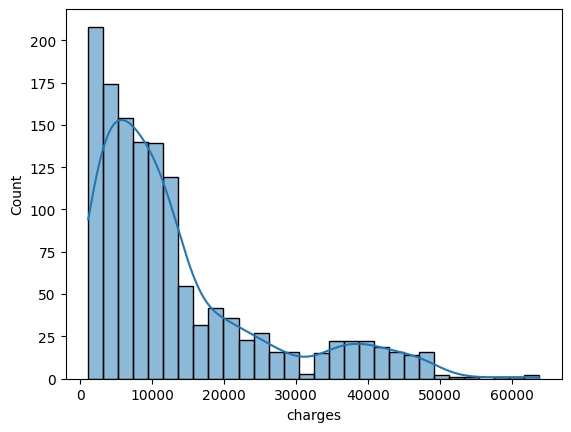

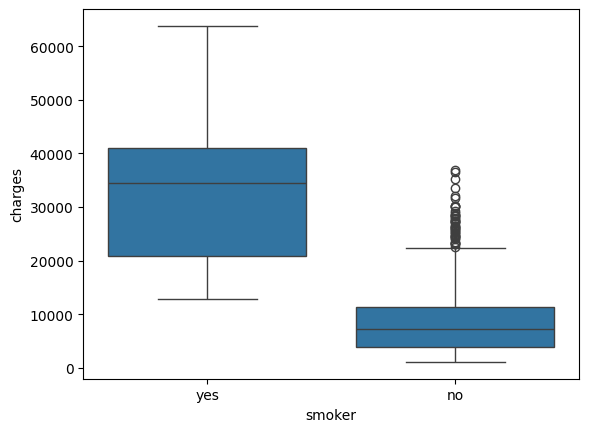

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data['charges'], kde=True)
plt.show()

sns.boxplot(x='smoker', y='charges', data=data)
plt.show()

In [14]:
data['bmi_category'] = pd.cut(data['bmi'],
                             bins=[0,18.5,25,30,100],
                             labels=['underweight','normal','overweight','obese'])

data['age_bmi'] = data['age'] * data['bmi']

In [15]:
data = pd.get_dummies(data, drop_first=True)

In [16]:
data.head()

,age,bmi,children,charges,age_bmi,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest,bmi_category_normal,bmi_category_overweight,bmi_category_obese
0,19,27.900,0,16884.92400,530.100,False,True,False,False,True,False,True,False
1,18,33.770,1,1725.55230,607.860,True,False,False,True,False,False,False,True
2,28,33.000,3,4449.46200,924.000,True,False,False,True,False,False,False,True
3,33,22.705,0,21984.47061,749.265,True,False,True,False,False,True,False,False
4,32,28.880,0,3866.85520,924.160,True,False,True,False,False,False,True,False


In [17]:
from sklearn.model_selection import train_test_split

X = data.drop('charges', axis=1)
y = data['charges']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))